In [2]:
#General imports
resol = 300
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter
import pandas as pd

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
})

import sys
import numpy as np
from pathlib import Path
pi = np.pi

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))

#Local imports
from experiments.coincidence_vs_rkstep import run_coincidence_vs_rkstep

<h1> Run the experiment </h1>

In [3]:
#Physical parameters
omega_A = 10*pi
Gamma = 5*pi

#Order of the bare parameters
n = 3

#Choose photon frequency
omega_q = 9*pi
delta_q = 0.05*pi

#Prepare frequency windows
frequency_window = [(0*pi, 20*pi),
                    (0*pi, 25*pi),
                    (2*pi, 20*pi),
                    (2*pi, 25*pi),
                    (0*pi, 24*pi),
                    (0*pi, 22*pi),
                    (2*pi, 22*pi)]


#Parameters of the simulation
L = 50

#Different parameterization of RK scheme
T = L/2
nb_pts_rk = 20
N_step_tab = np.logspace(1,3.8, nb_pts_rk)

param_cavity_physical = {'omega_A': omega_A, 'Gamma': Gamma, 'L': L}

param_photons = {'omega_p': [omega_q, omega_q], 
                 'delta_k': [delta_q, delta_q],
                 'x_0': [-L/4, -L/4]}

Run the experiment

In [5]:
for i in range(len(frequency_window)-3, len(frequency_window)):
    index_experiment = i+1
    cutoffs = {'ir_cutoff' : frequency_window[i][0], 'uv_cutoff' : frequency_window[i][1]}
    print(f'Treating frequency window {index_experiment} out of {len(frequency_window)}')

    run_coincidence_vs_rkstep(param_photons, param_cavity_physical, T, N_step_tab, cutoffs, 
                                n,index_experiment)

Treating frequency window 5 out of 7


100%|██████████| 20/20 [25:34<00:00, 76.74s/it] 


Treating frequency window 6 out of 7


100%|██████████| 20/20 [20:47<00:00, 62.36s/it] 


Treating frequency window 7 out of 7


100%|██████████| 20/20 [17:30<00:00, 52.52s/it] 


<h1> Results </h1>

Load the data

In [8]:
index_experiment = 3
R_theory_physical = 1 / (1 + ((omega_q - omega_A)/ (Gamma/2))**2)
theoretical_val = 1 - 4*R_theory_physical*(1-R_theory_physical)


coincidence_to_plot = []
relative_error_to_plot = []
N_step_tab_to_plot = []

for n in range(-1,4):
    if n == -1:
        data_file = f"../results/csv_files/coincidence_vs_rkstep_norenorm_{index_experiment}.csv"
    else:
        data_file = f"../results/csv_files/coincidence_vs_rkstep_n{n}_{index_experiment}.csv"

    df = pd.read_csv(data_file)
    coincidence_to_plot.append(df['coincidence_tab'].to_numpy())
    N_step_tab_to_plot.append(df['N_step_tab'].to_numpy())

    relative_error_to_plot.append(np.abs(coincidence_to_plot[-1] - theoretical_val)/theoretical_val)

Create the figure

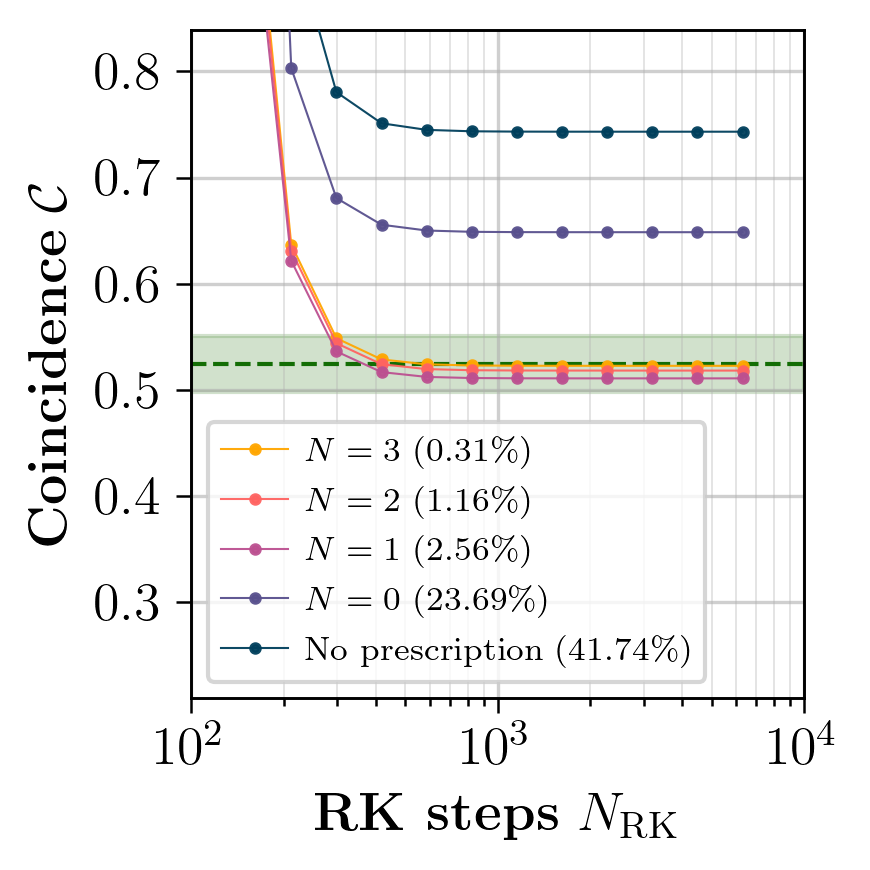

In [11]:
fig, ax = plt.subplots(figsize=(3, 3), dpi=300)

# Palette plus contrastée et adaptée print
colors = ["#ffa600","#ff6361", "#bc5090", "#58508d", "#003f5c"]
colors = colors[::-1]

labels  = [r'No prescription', r'$N=0$', r'$N=1$', r'$N=2$', r'$N=3$']

N_step_conv = np.zeros(5)

# -----------------------
# Curves
# -----------------------
for i in range(4,-1,-1):

    labels[i] += rf' ({relative_error_to_plot[i][-1]*100:.2f}\%)'

    ax.plot(
        N_step_tab_to_plot[i],
        coincidence_to_plot[i],
        color=colors[i],
        label=labels[i],
        marker="o",
        markersize =2,
        linewidth=0.5,
        alpha=0.95,
        zorder=3
    )

# -----------------------
# 5% confidence region 
# -----------------------
ax.axhline(theoretical_val,
           color='#136d05',
           linewidth=1,
           linestyle='--',
           zorder=2)

ax.fill_between(
    [1e2, 1e4],
    0.95*theoretical_val,
    1.05*theoretical_val,
    color='#679e56',
    alpha=0.3,
    zorder=1
)

# -----------------------
# Axes
# -----------------------
ax.set_xscale('log')
ax.set_xlim(1e2, 1e4)
ax.set_ylim([0.4*theoretical_val, 1.6*theoretical_val])

ax.set_xlabel(r'\textbf{RK steps} $N_{\rm RK}$')
ax.set_ylabel(r'\textbf{Coincidence} $\mathcal{C}$')

# -----------------------
# Log ticks + grid
# -----------------------
major_locator = LogLocator(base=10.0)
minor_locator = LogLocator(base=10.0, subs=np.arange(2,10)*0.1)

ax.xaxis.set_major_locator(major_locator)
ax.xaxis.set_minor_locator(minor_locator)
ax.xaxis.set_minor_formatter(NullFormatter())

ax.grid(which='major', linewidth=0.8, alpha=0.6)
ax.grid(which='minor', linewidth=0.4, alpha=0.4)

# -----------------------
# Legend 
# -----------------------
ax.legend(
    prop={'size': 8},
    handletextpad=0.5,   # espace symbole ↔ texte
    loc="lower left"
)

#font size
for item in [ax.xaxis.label, ax.yaxis.label]:
    item.set_fontsize(13)

for item in (ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(13)

plt.tight_layout()
plt.savefig(f"../results/fig/coincidence_vs_rkstep_{index_experiment}.pdf", bbox_inches="tight")
plt.show()

<h2> Other proposal </h2>

Other proposal : plot the relative error against $N$ for all experiments and forget about the number of RK steps at this stage. Prepare the data first

In [37]:
R_theory_physical = 1 / (1 + ((omega_q - omega_A)/ (Gamma/2))**2)
theoretical_val = 1 - 4*R_theory_physical*(1-R_theory_physical)


N_tab = np.arange(-1,4)
relative_error_to_plot = []
experiments_to_keep = [4,5,6,2]

for i in experiments_to_keep:
    index_experiment = i+1
    curve_to_add = np.zeros(len(N_tab))
    for j in range(len(N_tab)):
        n = N_tab[j]
        if n == -1:
            data_file = f"../results/csv_files/coincidence_vs_rkstep_norenorm_{index_experiment}.csv"
        else:
            data_file = f"../results/csv_files/coincidence_vs_rkstep_n{n}_{index_experiment}.csv"

        df = pd.read_csv(data_file)
        coincidence_tab = df['coincidence_tab'].to_numpy()
        curve_to_add[j] = np.abs(coincidence_tab[-1] - theoretical_val)/theoretical_val
        
    relative_error_to_plot.append(curve_to_add)

Create the figure

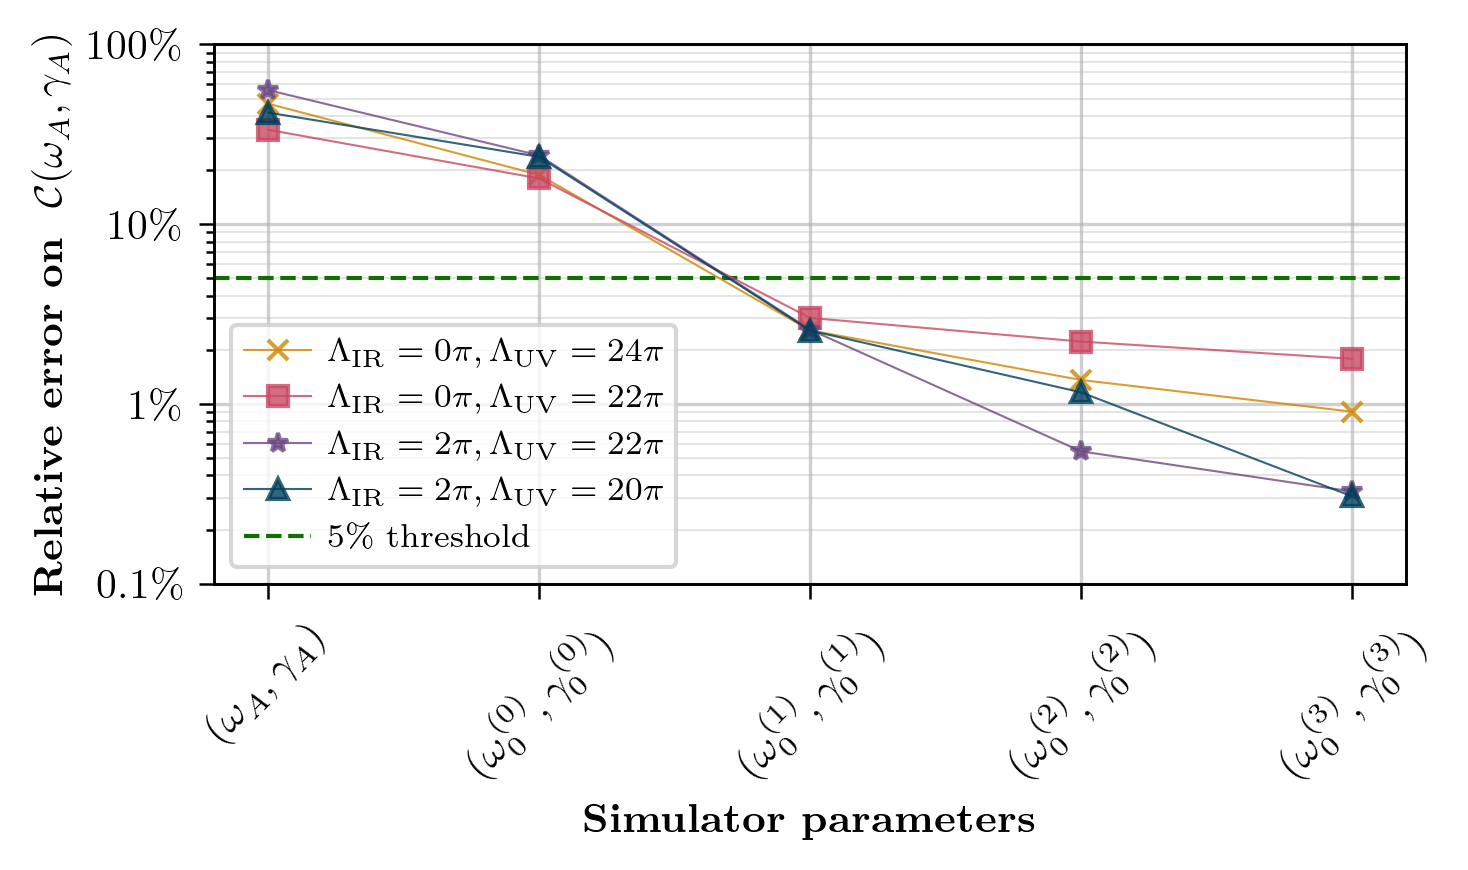

In [48]:
fig, ax = plt.subplots(figsize=(5, 3), dpi=300)

# Palette plus contrastée et adaptée print
#colors = ["#ffa600","#ff6361", "#bc5090", "#58508d", "#003f5c"]

label_full = [r'$\Lambda_{\rm IR} = 0\pi, \Lambda_{\rm UV} = 20\pi$',
              r'$\Lambda_{\rm IR} = 0\pi, \Lambda_{\rm UV} = 25\pi$',
              r'$\Lambda_{\rm IR} = 2\pi, \Lambda_{\rm UV} = 20\pi$',
              r'$\Lambda_{\rm IR} = 2\pi, \Lambda_{\rm UV} = 25\pi$',
              r'$\Lambda_{\rm IR} = 0\pi, \Lambda_{\rm UV} = 24\pi$',
              r'$\Lambda_{\rm IR} = 0\pi, \Lambda_{\rm UV} = 22\pi$',
              r'$\Lambda_{\rm IR} = 2\pi, \Lambda_{\rm UV} = 22\pi$']

marker_full = ['o', '+', '^', 'd', 'x', 's', '*']

color_full = ["#ffa600", "#ff764a", "#ef5675", "#bc5090", "#7a5195", "#374c80", "#003f5c"]

#colors = [color_full[i] for i in experiments_to_keep]

colors = ["#cf8600", "#c94862", "#6d4984", "#003f5c"]
markers = [marker_full[i] for i in experiments_to_keep]
labels = [label_full[i] for i in experiments_to_keep]

# -----------------------
# Curves
# -----------------------
for i in range(len(experiments_to_keep)):

    ax.plot(
        N_tab,
        relative_error_to_plot[i],
        label=labels[i],
        color = colors[i],
        marker=markers[i],
        markersize =5,
        linewidth=0.5,
        alpha=0.8,
        zorder=3
    )

# -----------------------
# 5% confidence region 
# -----------------------
ax.axhline(0.05,
           color='#136d05',
           linewidth=1,
           linestyle='--',
           zorder=2,
           label='5\\% threshold')

# -----------------------
# Axes
# -----------------------
ax.set_xticks(N_tab)
ax.set_xticklabels([r'$(\omega_A, \gamma_A)$', 
                    r'$(\omega_0^{(0)}, \gamma_0^{(0)})$', 
                    r'$(\omega_0^{(1)}, \gamma_0^{(1)})$',
                    r'$(\omega_0^{(2)}, \gamma_0^{(2)})$',
                    r'$(\omega_0^{(3)}, \gamma_0^{(3)})$'])
ax.tick_params(axis='x', labelrotation=45)
ax.set_xlabel(r'\textbf{Simulator parameters}')

ax.set_yscale('log')
ax.set_ylim([1e-3, 1e0])

ax.set_yticks([1e0, 1e-1, 1e-2, 1e-3])
ax.set_yticklabels([r'$100\%$', 
                    r'$10\%$', 
                    r'$1\%$',
                    r'$0.1\%$'])
ax.set_ylabel(r'\textbf{Relative error on } $\mathcal{C}(\omega_A, \gamma_A)$')

# -----------------------
# Log ticks + grid
# -----------------------
major_locator = LogLocator(base=10.0)
minor_locator = LogLocator(base=10.0, subs=np.arange(2,10)*0.1)

ax.yaxis.set_major_locator(major_locator)
ax.yaxis.set_minor_locator(minor_locator)
ax.yaxis.set_minor_formatter(NullFormatter())

ax.grid(which='major', linewidth=0.8, alpha=0.6)
ax.grid(which='minor', linewidth=0.4, alpha=0.4)

# -----------------------
# Legend 
# -----------------------
ax.legend(
    prop={'size': 8},
    handletextpad=0.5,   # espace symbole ↔ texte
    loc="lower left"
)

#font size
for item in [ax.xaxis.label, ax.yaxis.label]:
    item.set_fontsize(10)

for item in (ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(10)

plt.tight_layout()
plt.savefig(f"../results/fig/coincidence_vs_N.pdf", bbox_inches="tight")
plt.show()